# TI benchmark figures

This notebook redraws the completed TI benchmark without rerunning the simulator or any TI method. It reads the saved metrics, experiment settings, and fixed UMAP coordinates.

Choose `direction` or `endpoint` below, adjust the small group of style settings, then run all cells. Figures are written to a separate `figures_notebook/` directory so exploratory edits do not overwrite the formal outputs.

In [152]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    'font.size': 9,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Run and style controls

These are the settings you are most likely to adjust.

In [153]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'experiments').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]  # when the kernel starts in experiments/notebooks
if not (PROJECT_ROOT / 'experiments').is_dir():
    raise RuntimeError('Run this notebook from the scDeepSim repository.')

RUNS = {
    'direction': PROJECT_ROOT / 'experiments/outputs/ti_benchmark_direction_v2_native/results/1bb61b2e7c38_5f368025a379',
    'endpoint': PROJECT_ROOT / 'experiments/outputs/ti_benchmark_full_native/results/949dd7953626_fd09da8d0988',
}
RUN_NAME = 'direction'  # change to 'endpoint' for the other benchmark
RUN_DIR = RUNS[RUN_NAME]
OUTPUT_DIR = RUN_DIR / 'figures_notebook'
SAVE_FIGURES = False
DPI = 300

# Sizes for the standalone UMAP panels
UMAP_PANEL_SIZE = (14, 2.8)
PANEL_REAL_POINT_SIZE = 5
PANEL_SYNTHETIC_POINT_SIZE = 5

# Sizes for the compact paper figure
COMPACT_SIZE = (12, 6.5)
COMPACT_WIDTH_RATIOS = (0.8, 0.2)
COMPACT_REAL_POINT_SIZE = 2
COMPACT_SYNTHETIC_POINT_SIZE = 2
COMPACT_SCORE_POINT_SIZE = 5

## Load the completed experiment

The UMAP coordinates were already produced with the real-data-fitted PCA and UMAP models. This notebook only reads and displays them.

In [154]:
with (RUN_DIR / 'experiment_settings.json').open() as handle:
    experiment = json.load(handle)

settings = experiment['settings']
metrics = pd.read_csv(RUN_DIR / 'metrics.csv')
summary = pd.read_csv(RUN_DIR / 'metrics_summary.csv')
real_umap = pd.read_csv(RUN_DIR / 'plot_data/real_umap_reference.csv')

axis_order = tuple(dict.fromkeys(setting['axis'] for setting in settings))
methods = experiment['methods']
axis_frames = {
    axis: pd.read_csv(RUN_DIR / 'plot_data' / f'umap_plot_data_{axis}.csv')
    for axis in axis_order
}
values_by_axis = {
    axis: [float(s['value']) for s in settings if s['axis'] == axis]
    for axis in axis_order
}
value_labels_by_axis = {
    axis: [str(s['value_label']) for s in settings if s['axis'] == axis]
    for axis in axis_order
}

all_x = [real_umap['umap_1']] + [frame['umap_1'] for frame in axis_frames.values()]
all_y = [real_umap['umap_2']] + [frame['umap_2'] for frame in axis_frames.values()]
all_x = pd.concat(all_x, ignore_index=True).to_numpy()
all_y = pd.concat(all_y, ignore_index=True).to_numpy()
x_margin = 0.04 * np.ptp(all_x)
y_margin = 0.04 * np.ptp(all_y)
xlim = (all_x.min() - x_margin, all_x.max() + x_margin)
ylim = (all_y.min() - y_margin, all_y.max() + y_margin)

print(f'Loaded {RUN_NAME}: {len(metrics)} method runs, axes = {axis_order}')

Loaded direction: 225 method runs, axes = ('direction_discrepancy', 'tau', 'noise_scale')


## Shared visual language

In [155]:
axis_labels = {
    'discrepancy': r'Endpoint displacement ($\delta$)',
    'direction_discrepancy': r'Direction discrepancy ($1-\cos\theta$)',
    'tau': r'Branch time ($\tau$)',
    'noise_scale': 'Noise scale',
}
row_labels = {
    'discrepancy': r'$\delta$',
    'direction_discrepancy': r'$1-\cos\theta$',
    'tau': r'$\tau$',
    'noise_scale': r'$\sigma$',
}
method_colors = {
    'scanpy_dpt_paga': '#0072B2',
    'slingshot': '#D55E00',
    'monocle3': '#009E73',
}
method_markers = {
    'scanpy_dpt_paga': 'o',
    'slingshot': 's',
    'monocle3': '^',
}
method_labels = {
    'scanpy_dpt_paga': 'DPT/PAGA',
    'slingshot': 'Slingshot',
    'monocle3': 'Monocle3',
}
lineage_colormaps = {
    'trunk': 'Greens',
    'branch_B': 'Blues',
    'branch_C': 'Oranges',
}

In [156]:
def save_figure(fig, name):
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / f'{name}.png', dpi=DPI, bbox_inches='tight')
        fig.savefig(OUTPUT_DIR / f'{name}.pdf', bbox_inches='tight')


def draw_umap(ax, panel, real_size, synthetic_size):
    ax.scatter(
        real_umap['umap_1'], real_umap['umap_2'],
        s=real_size, color='#C8C8C8', alpha=0.20, linewidths=0, rasterized=True,
    )
    for lineage in ('trunk', 'branch_B', 'branch_C'):
        cells = panel[panel['true_lineage'] == lineage]
        colors = plt.get_cmap(lineage_colormaps[lineage])(
            0.22 + 0.76 * cells['true_pseudotime'].to_numpy()
        )
        ax.scatter(
            cells['umap_1'], cells['umap_2'],
            s=synthetic_size, c=colors, alpha=0.80, linewidths=0, rasterized=True,
        )
    ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[])
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_color('#777777')
        spine.set_linewidth(0.5)


def draw_metric_axis(ax, axis, compact=False):
    values = values_by_axis[axis]
    raw_size = COMPACT_SCORE_POINT_SIZE if compact else 20
    line_width = 1.15 if compact else 2
    marker_size = 3 if compact else 5

    for method_index, method in enumerate(methods):
        color = method_colors[method]
        marker = method_markers[method]
        raw = metrics.query(
            'axis == @axis and method == @method and status == \"ok\"'
        ).sort_values(['value', 'replicate'])
        curve = summary.query(
            'axis == @axis and method == @method'
        ).sort_values('value')

        x = curve['value'].to_numpy(float)
        mean = curve['mean'].to_numpy(float)
        sd = curve['sd'].to_numpy(float)
        n_valid = curve['n_valid'].to_numpy(int)
        n_attempted = curve['n_attempted'].to_numpy(int)
        jitter = (method_index - 1) * max(np.ptp(x), 1.0) * 0.006

        ax.scatter(
            raw['value'] + jitter, raw['spearman_global'],
            s=raw_size, color=color, marker=marker, alpha=0.25, linewidths=0,
        )
        band = (n_valid >= 2) & np.isfinite(mean) & np.isfinite(sd)
        ax.fill_between(
            x, np.where(band, mean - sd, np.nan), np.where(band, mean + sd, np.nan),
            color=color, alpha=0.14,
        )
        ax.plot(
            x, mean, color=color, marker=marker, linewidth=line_width,
            markersize=marker_size, label=method_labels[method],
        )

        for value, score, valid, attempted in zip(x, mean, n_valid, n_attempted):
            if valid == attempted:
                continue
            if valid == 0:
                score = -0.93 + 0.07 * method_index
                ax.scatter(value + jitter, score, marker='x', color=color, s=12)
            ax.annotate(
                f'{valid}/{attempted}', (value, score), xytext=(0, 4),
                textcoords='offset points', ha='center', color=color,
                fontsize=4.2 if compact else 7,
            )

    ax.set_ylim(-1, 1)
    ax.set_xticks(values, value_labels_by_axis[axis])
    ax.grid(alpha=0.20, linestyle='--', linewidth=0.5)
    ax.set_xlabel(axis_labels[axis])

In [157]:
lineage_handles = [
    Line2D([], [], marker='o', markersize=4, linestyle='', color='#C8C8C8', label='Real'),
    Line2D([], [], marker='o', markersize=4, linestyle='', color=plt.get_cmap('Greens')(0.68), label='Trunk'),
    Line2D([], [], marker='o', markersize=4, linestyle='', color=plt.get_cmap('Blues')(0.68), label='Branch B'),
    Line2D([], [], marker='o', markersize=4, linestyle='', color=plt.get_cmap('Oranges')(0.68), label='Branch C'),
    Line2D([], [], linewidth=0, label='Pseudotime: early → late'),
]
method_handles = [
    Line2D(
        [], [], color=method_colors[method], marker=method_markers[method],
        linewidth=1.2, markersize=3, label=method_labels[method],
    )
    for method in methods
]

## Global Spearman: 1 × 3

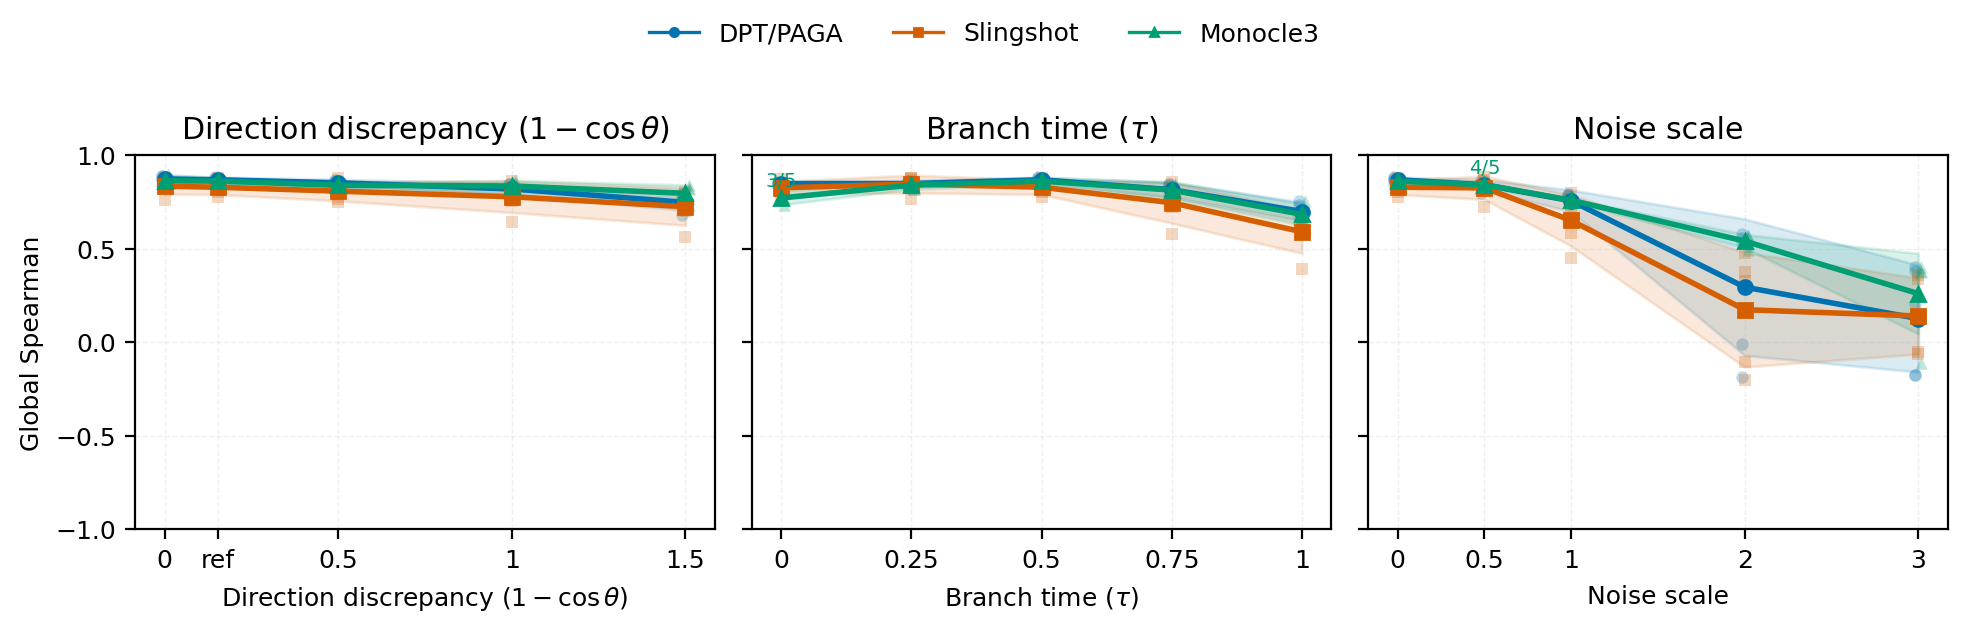

In [158]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharey=True)
for ax, axis in zip(axes, axis_order):
    draw_metric_axis(ax, axis)
    ax.set_title(axis_labels[axis])
axes[0].set_ylabel('Global Spearman')
fig.legend(handles=method_handles, loc='upper center', ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.88))
save_figure(fig, 'global_spearman_1x3')
plt.show()

## Compact paper figure: 3 × 5 UMAPs plus aligned score panels

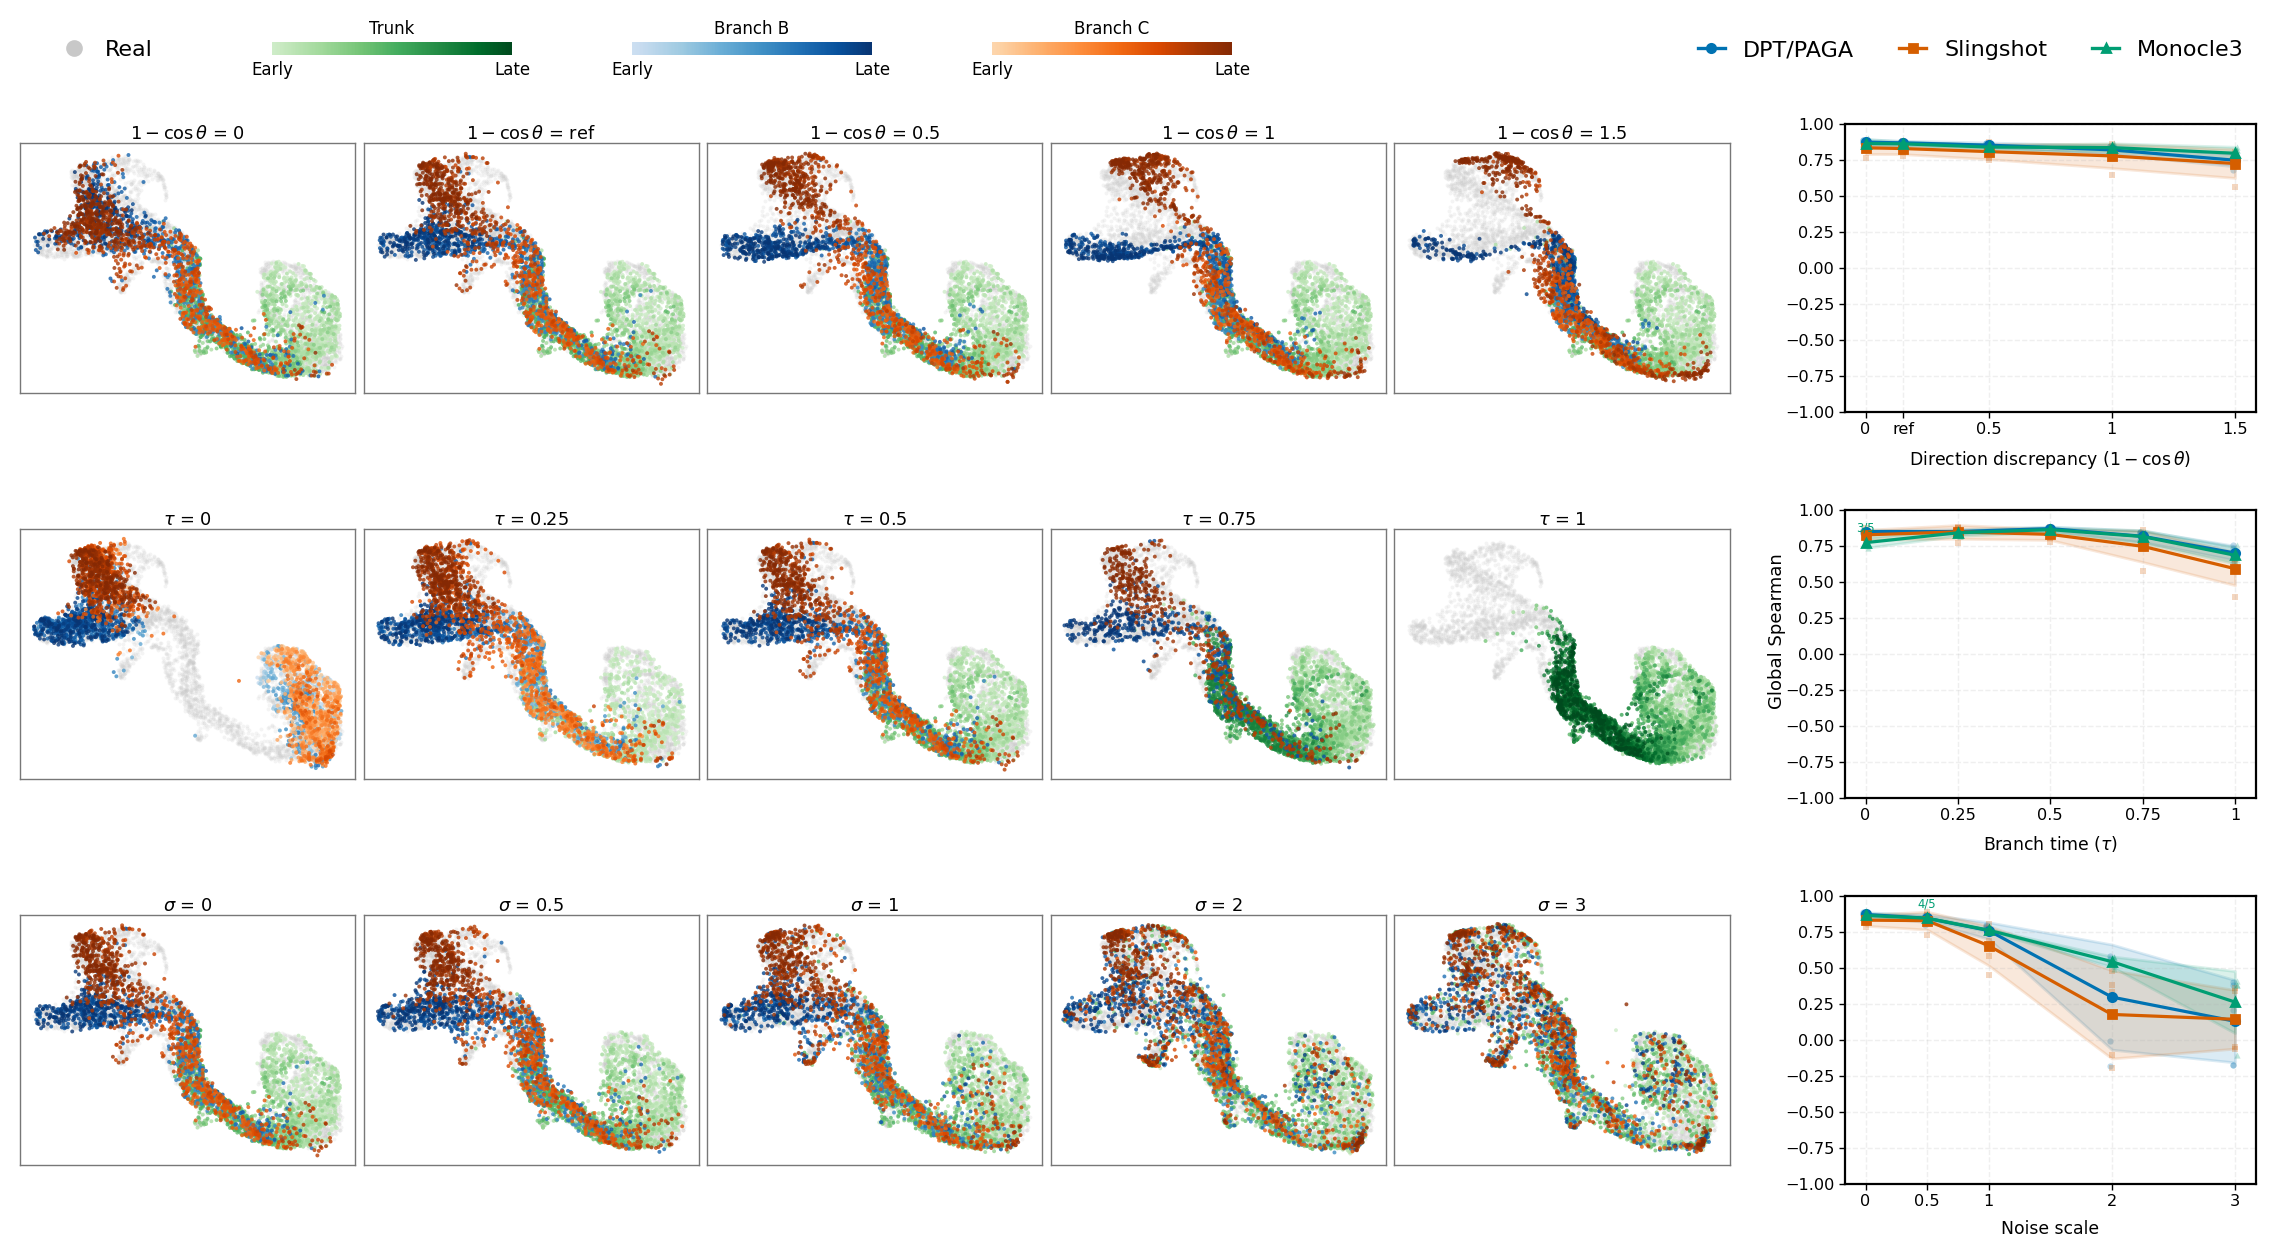

In [192]:
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=COMPACT_SIZE)
outer = fig.add_gridspec(
    3, 2, width_ratios=COMPACT_WIDTH_RATIOS,
    left=0.055, right=0.99, bottom=0.075, top=0.89,
    wspace=0.10, hspace=0.34,
)
umap_axes = []
metric_axes = []

for row, axis in enumerate(axis_order):
    left_grid = outer[row, 0].subgridspec(1, 5, wspace=0.025)
    row_axes = []
    frame = axis_frames[axis]
    for column, (value, label) in enumerate(zip(values_by_axis[axis], value_labels_by_axis[axis])):
        ax = fig.add_subplot(left_grid[0, column])
        panel = frame[np.isclose(frame['value'], value)]
        draw_umap(ax, panel, COMPACT_REAL_POINT_SIZE, COMPACT_SYNTHETIC_POINT_SIZE)
        ax.set_title(rf'{row_labels[axis]} = {label}', fontsize=6.4, pad=1.5)
        row_axes.append(ax)
    umap_axes.append(row_axes)

    ax = fig.add_subplot(outer[row, 1])
    draw_metric_axis(ax, axis, compact=True)
    ax.set_box_aspect(0.7)
    ax.tick_params(axis='both', labelsize=5.8, width=0.5, length=2.2, pad=1.5)
    ax.xaxis.label.set_size(6.2)
    metric_axes.append(ax)
    
fig.legend(
    handles=[
        Line2D(
            [], [], marker='o', linestyle='None',
            color='#C8C8C8', markersize=5, label='Real',
        )
    ],
    loc='upper left',
    bbox_to_anchor=(0.060, 0.970),
    frameon=False,
    fontsize=8,
    handletextpad=0.4,
)

gradient_specs = [
    ('trunk',    'Trunk',    [0.16, 0.943, 0.10, 0.01]),
    ('branch_B', 'Branch B', [0.31, 0.943, 0.10, 0.01]),
    ('branch_C', 'Branch C', [0.46, 0.943, 0.10, 0.01]),
]

for lineage, label, position in gradient_specs:
    base_cmap = plt.get_cmap(lineage_colormaps[lineage])
    cmap = LinearSegmentedColormap.from_list(
        f'{lineage}_pseudotime',
        base_cmap(np.linspace(0.22, 0.98, 256)),
    )

    cax = fig.add_axes(position)
    cb = fig.colorbar(
        ScalarMappable(norm=Normalize(0, 1), cmap=cmap),
        cax=cax,
        orientation='horizontal',
    )
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['Early', 'Late'])
    cb.ax.tick_params(labelsize=6, length=0, pad=2)
    cb.ax.set_title(label, fontsize=6, pad=3)
    cb.outline.set_visible(False)

# fig.text(
#     0.36, 0.900, 'True pseudotime',
#     ha='center', va='center', fontsize=7,
# )

metric_left = min(ax.get_position().x0 for ax in metric_axes)
fig.text(
    metric_left - 0.028, 0.50, 'Global Spearman', rotation=90,
    fontsize=6.5, ha='center', va='center',
)
fig.legend(
    handles=method_handles, loc='upper right', bbox_to_anchor=(0.99, 0.970),
    frameon=False, fontsize=8, handlelength=1.25, ncol=3
)

plt.show()